In [6]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

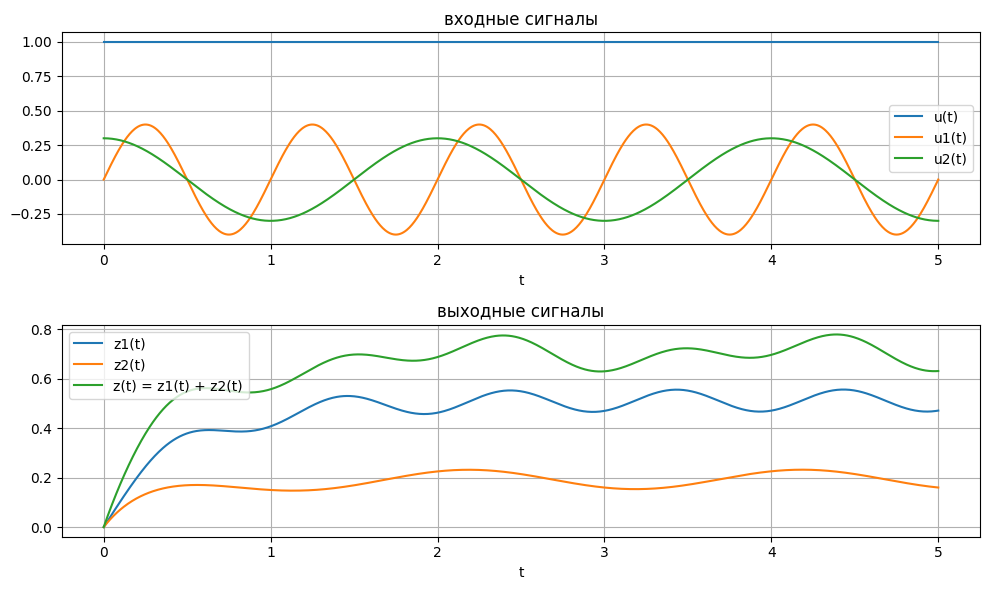

In [7]:
# блок G1: 2 состояния, входы [u, u1], выход z1
A1 = [[-2.0, 0.0],
      [ 0.0,-5.0]]
B1 = [[1.0, 0.5],
      [0.2, 1.0]]
C1 = [[1.0, 0.3]]
D1 = [[0.0, 0.0]]

G1 = ct.ss(
    A1, B1, C1, D1,
    inputs=['u', 'u1'],
    outputs=['z1'],
    name='G1'
)

# блок G2: 2 состояния, входы [u, u2], выход z2
A2 = [[-3.0, 0.0],
      [ 0.0,-8.0]]
B2 = [[0.8, 0.4],
      [0.1, 1.2]]
C2 = [[0.7, 0.5]]
D2 = [[0.0, 0.0]]

G2 = ct.ss(
    A2, B2, C2, D2,
    inputs=['u', 'u2'],
    outputs=['z2'],
    name='G2'
)

# объединение систем
G = ct.interconnect(
    [G1, G2],
    inplist=[
        ['G1.u', 'G2.u'],
        'G1.u1',
        'G2.u2'
    ],
    outlist=[
        'G1.z1',
        'G2.z2',
        ['G1.z1', 'G2.z2']
    ]
)

t = np.linspace(0, 5, 1000)
u  = np.ones_like(t)
u1 = 0.4 * np.sin(2 * np.pi * 1.0 * t)
u2 = 0.3 * np.cos(2 * np.pi * 0.5 * t)

U = np.vstack([u, u1, u2])

t_out, y_out = ct.forced_response(G, T=t, U=U)

z1 = y_out[0]
z2 = y_out[1]
z  = y_out[2]

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, u,  label='u(t)')
plt.plot(t, u1, label='u1(t)')
plt.plot(t, u2, label='u2(t)')
plt.title('входные сигналы')
plt.xlabel('t')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_out, z1, label='z1(t)')
plt.plot(t_out, z2, label='z2(t)')
plt.plot(t_out, z,  label='z(t) = z1(t) + z2(t)')
plt.title('выходные сигналы')
plt.xlabel('t')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

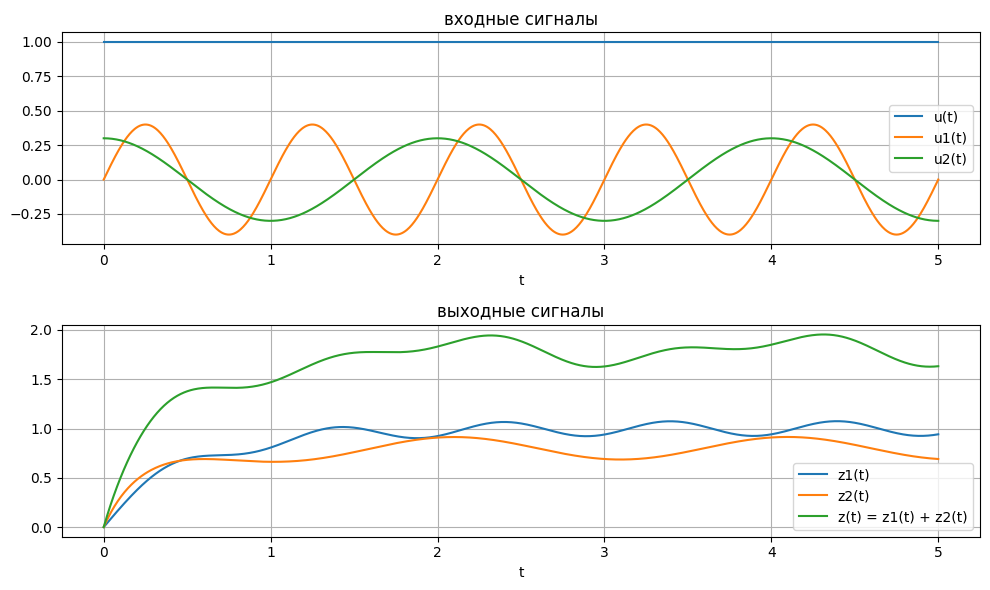

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# каналы блока G1:
# z1 = G11 * u + G12 * u1
G11 = signal.TransferFunction([1.0], [0.5, 1.0])
G12 = signal.TransferFunction([0.3], [0.2, 1.0])

# каналы блока G2:
# z2 = G21 * u + G22 * u2
G21 = signal.TransferFunction([0.8], [0.3, 1.0])
G22 = signal.TransferFunction([0.4], [0.1, 1.0])

# временная сетка
t = np.linspace(0, 5, 1000)

# входные сигналы
u  = np.ones_like(t)
u1 = 0.4 * np.sin(2 * np.pi * 1.0 * t)
u2 = 0.3 * np.cos(2 * np.pi * 0.5 * t)

# отклики по отдельным каналам
_, y11, _ = signal.lsim(G11, U=u,  T=t)
_, y12, _ = signal.lsim(G12, U=u1, T=t)
_, y21, _ = signal.lsim(G21, U=u,  T=t)
_, y22, _ = signal.lsim(G22, U=u2, T=t)

# выходы блоков
z1 = y11 + y12
z2 = y21 + y22

# суммарный выход
z = z1 + z2

# графики
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, u,  label='u(t)')
plt.plot(t, u1, label='u1(t)')
plt.plot(t, u2, label='u2(t)')
plt.title('входные сигналы')
plt.xlabel('t')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, z1, label='z1(t)')
plt.plot(t, z2, label='z2(t)')
plt.plot(t, z,  label='z(t) = z1(t) + z2(t)')
plt.title('выходные сигналы')
plt.xlabel('t')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

### Пример из текста методички

Та же схема параллельного соединения, собранная из скалярных передаточных функций и сумматоров. Многомерную передаточную функцию (`ct.combine_tf`) `interconnect` без пакета `slycot` в пространство состояний не переводит, а скалярные блоки переводятся без него.

In [ ]:
G11 = ct.tf([1.0], [0.5, 1.0], inputs='u',  outputs='y11', name='G11')
G12 = ct.tf([0.3], [0.2, 1.0], inputs='u1', outputs='y12', name='G12')
G21 = ct.tf([0.8], [0.3, 1.0], inputs='u',  outputs='y21', name='G21')
G22 = ct.tf([0.4], [0.1, 1.0], inputs='u2', outputs='y22', name='G22')

# сумматоры: z1 = y11 + y12, z2 = y21 + y22, z = z1 + z2
S1 = ct.summing_junction(inputs=['y11', 'y12'], output='z1', name='S1')
S2 = ct.summing_junction(inputs=['y21', 'y22'], output='z2', name='S2')
S3 = ct.summing_junction(inputs=['z1', 'z2'], output='z', name='S3')

# соединение по именам сигналов
G = ct.interconnect([G11, G12, G21, G22, S1, S2, S3],
                    inplist=['u', 'u1', 'u2'],
                    outlist=['z1', 'z2', 'z'])

t = np.linspace(0, 5, 1000)
U = np.vstack([np.ones_like(t),
               0.4 * np.sin(2 * np.pi * 1.0 * t),
               0.3 * np.cos(2 * np.pi * 0.5 * t)])
t_out, y_out = ct.forced_response(G, T=t, U=U)

for y, name in zip(y_out, ['z1', 'z2', 'z']):
    plt.plot(t_out, y, label=name)
plt.legend()
plt.grid()
plt.show()

### Пример из текста методички

Соединение по отрицательной обратной связи: $G_{cl} = G_{op}/(1 + G_{op}K)$.

In [ ]:
s = ct.tf('s')
G_op = 5 / (s + 1)
K = 2 / (0.5 * s + 1)

G_cl = ct.feedback(G_op, K)            # отрицательная обратная связь
G_pos = ct.feedback(G_op, K, sign=1)   # положительная обратная связь
print(G_cl)
print("полюса при положительной обратной связи:", G_pos.poles())

t = np.linspace(0, 10, 1000)
t_out, y_out = ct.forced_response(G_cl, T=t, U=np.ones_like(t))
plt.plot(t_out, y_out)
plt.grid()
plt.show()

### Пример из текста методички

Многоканальная система с обратной связью по выходу $z_2$. Объект задан в пространстве состояний (по одному состоянию на канал), поэтому пакет `slycot` не нужен.

In [ ]:
# G_op(s) = [[1/(s+1), 0.5/(s+2)], [0.3/(s+3), 1/(s+1)]]
A = np.diag([-1.0, -2.0, -3.0, -1.0])
B = np.array([[1, 0],     # x1: канал u1 -> z1
              [0, 1],     # x2: канал u_sum -> z1
              [1, 0],     # x3: канал u1 -> z2
              [0, 1]])    # x4: канал u_sum -> z2
C = np.array([[1, 0.5, 0,   0],
              [0, 0,   0.3, 1]])
D = np.zeros((2, 2))
G_op = ct.ss(A, B, C, D, inputs=['u1', 'u_sum'], outputs=['z1', 'z2'], name='Gop')

# K(s): обратная связь
K = ct.tf([2], [1, 1], inputs=['z2'], outputs=['u_fb'], name='K')
# сумматор: u_sum = u2 - u_fb
S = ct.summing_junction(inputs=['u2', '-u_fb'], output='u_sum', name='sum')

G_cl = ct.interconnect(
    [G_op, K, S],
    connections=[
        ['K.z2', 'Gop.z2'],       # z2 -> K
        ['sum.u_fb', 'K.u_fb'],   # K -> сумматор
        ['Gop.u_sum', 'sum.u_sum']
    ],
    inplist=['Gop.u1', 'sum.u2'],
    outlist=['Gop.z1', 'Gop.z2']
)

t = np.linspace(0, 10, 1000)
u1 = np.ones_like(t)
u2 = 0.5 * np.sin(2 * np.pi * 0.5 * t)
t_out, y_out = ct.forced_response(G_cl, T=t, U=np.vstack([u1, u2]))

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, u1, label='u1(t)')
plt.plot(t, u2, label='u2(t)')
plt.title('входные сигналы')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t_out, y_out[0], label='z1(t)')
plt.plot(t_out, y_out[1], label='z2(t)')
plt.title('выходы системы')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()